In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os
print(sys.executable)
SRC_SUBDIR = '../..'
SRC_SUBDIR = os.path.abspath(SRC_SUBDIR)
if SRC_SUBDIR not in sys.path:
    print(f'Adding source directory to the sys.path: {SRC_SUBDIR!r}')
    sys.path.insert(1, SRC_SUBDIR)

/opt/homebrew/Caskroom/miniforge/base/envs/nlops/bin/python
Adding source directory to the sys.path: '/Volumes/Data/Projects/NLOperators'


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sir_modelling import simulate_epidemic

In [3]:
Npopulation = 1.0e7
sirmodpars = np.array([0.23, 0.11])
sirdata, tvalues, sirmod = simulate_epidemic(T = 280, dt = 0.1, Tsub=1.0, Npopulation = Npopulation, sir_model = sirmodpars)


{'units': 'days'}


In [4]:
def configure_dataset(sirdata, data_attributes):
    assert sirdata.shape[0] == len(tvalues)
    assert sirdata.shape[1] == len(data_attributes)

    dataset = [None]*sirdata.shape[1]
    for i, attrs in enumerate(data_attributes):
        datadict = attrs
        datadict["data"]=sirdata[:,i]
        dataset[i] = datadict
    return dataset

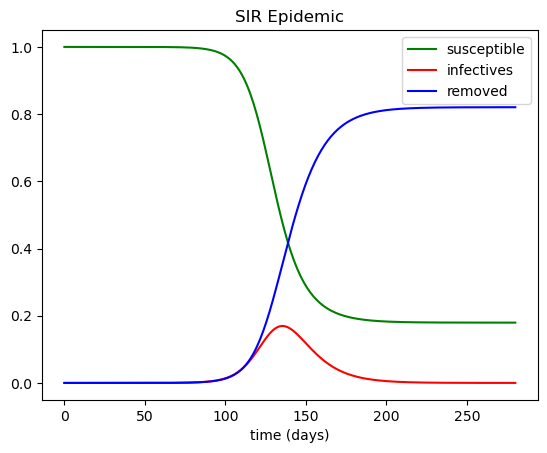

In [5]:
def plot_dataset(dataset, tvalues):
    
    assert sirdata.shape[0] == len(tvalues)
    nticks =11
    M = 1.0e6

    for attrs in dataset:
        data = attrs["data"]
        assert data.size == len(tvalues), f"{data.size=} != {len(tvalues)}"
        plt.plot(tvalues, attrs["data"], linestyle=attrs["linestyle"], label=attrs["label"], color=attrs["color"])
        #yticks = np.linspace(0, 1, num=nticks)
        #ylabels = [f"{value / M:.1f} M" for value in yticks] 
        #plt.yticks(yticks, labels=ylabels)
        plt.xlabel("time (days)")
    plt.title("SIR Epidemic")
    plt.legend()

sir_attributes = [
    {"linestyle":"-", "label": "susceptible", "color":"g"}, 
    {"linestyle":"-", "label": "infectives" , "color":"r"},
    {"linestyle":"-", "label": "removed"    , "color":"b"}
]
sirdataset = configure_dataset(sirdata, sir_attributes) 
plot_dataset(sirdataset, tvalues)

shape=(4,)
1 : [0.99997927 0.1122277  0.18       0.15      ]
2 : [0.99999532 0.1122295  0.17292694 0.1562034 ]
3 : [1.04446433 0.11224168 0.0533151  0.05114816]
4 : [1.04109402 0.11224114 0.04992071 0.04795297]
5 : [1.26123816 0.1122748  0.03927951 0.03348357]
6 : [1.22891773 0.11226736 0.03310305 0.02589275]
7 : [1.24304174 0.11226746 0.03353951 0.02498095]
8 : [1.14277069 0.1122456  0.03354261 0.02262645]
9 : [1.11641488 0.11223396 0.03577521 0.02340547]
10 : [1.10535553 0.11222615 0.03537231 0.02238152]
11 : [1.11038986 0.11222404 0.03575767 0.02289512]
12 : [1.10950341 0.11221991 0.03574118 0.02287566]
13 : [1.10870835 0.1122097  0.03572557 0.02285455]
14 : [1.10780974 0.11218911 0.03570883 0.02283096]
15 : [1.10662665 0.11214843 0.03568812 0.02280022]
16 : [1.1049277  0.11206802 0.0356605  0.02275658]
17 : [1.10236064 0.11190867 0.03562241 0.02269151]
18 : [1.09837416 0.11159225 0.03556983 0.02259207]
19 : [1.09214743 0.11096485 0.03550034 0.02243979]
20 : [1.08266413 0.10973684 0

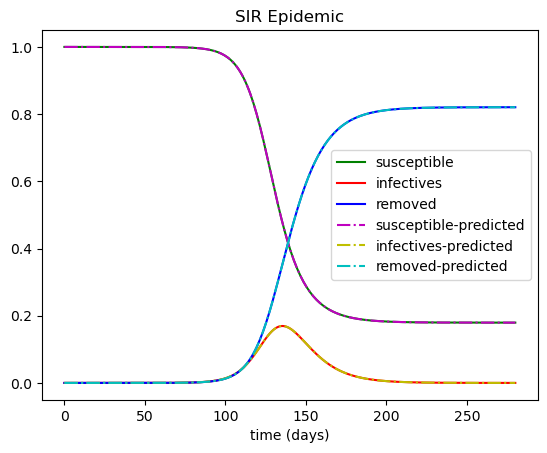

In [6]:
from sir_inversion import SIRInversion, SIRFixedInversion
sirinv = SIRInversion(sirmod=sirmod, data=sirdata)
sirpredicted, params = sirinv(x0 = np.array([1.0, 0.0, 0.18, 0.15]))
data_comparison = np.concatenate([sirdata, sirpredicted], axis=1)
data_attributes = [
    {"linestyle":"-", "label": "susceptible", "color":"g"}, 
    {"linestyle":"-", "label": "infectives" , "color":"r"},
    {"linestyle":"-", "label": "removed"    , "color":"b"},
    {"linestyle":"-.", "label": "susceptible-predicted", "color":"m"}, 
    {"linestyle":"-.", "label": "infectives-predicted" , "color":"y"},
    {"linestyle":"-.", "label": "removed-predicted"    , "color":"c"}
]
comparison = configure_dataset(data_comparison, data_attributes) 
plot_dataset(comparison, tvalues)

In [7]:
sirfixedinv = SIRFixedInversion.from_sirmod(sirmod=sirmod, data=sirdata, model0= np.array([0.2,0.1]))
sirfixed, params = sirfixedinv(x0 = np.array([1.0, 0.0]))
print(f"inversion_params = {params}")


shape=(2,)
1 : [1.00000000e+00 2.34164558e-08]
2 : [1.20127766e+00 2.34189400e-08]
3 : [1.14556967e+00 2.34183098e-08]
4 : [1.14976107e+00 2.34184204e-08]
5 : [1.14951223e+00 2.34184770e-08]
6 : [1.14940883e+00 2.34188418e-08]
7 : [1.14932671e+00 2.34195532e-08]
8 : [1.14886022e+00 2.34263252e-08]
9 : [1.14834859e+00 2.34392007e-08]
10 : [1.14780721e+00 2.34613425e-08]
11 : [1.14716034e+00 2.35002770e-08]
12 : [1.14629674e+00 2.35712079e-08]
13 : [1.14505419e+00 2.37036256e-08]
14 : [1.14318229e+00 2.39544667e-08]
15 : [1.14029924e+00 2.44326817e-08]
16 : [1.13588122e+00 2.53402723e-08]
17 : [1.12944433e+00 2.70163883e-08]
18 : [1.12124164e+00 2.98911223e-08]
19 : [1.11272312e+00 3.43472089e-08]
20 : [1.10512754e+00 4.11454084e-08]
21 : [1.09940838e+00 5.23567755e-08]
22 : [1.09645499e+00 7.40510003e-08]
23 : [1.09389263e+00 1.00091030e-07]
24 : [1.08604686e+00 1.37614839e-07]
25 : [1.07152482e+00 1.95316817e-07]
26 : [1.05651200e+00 2.68033453e-07]
27 : [1.04694391e+00 3.43604460e-07]

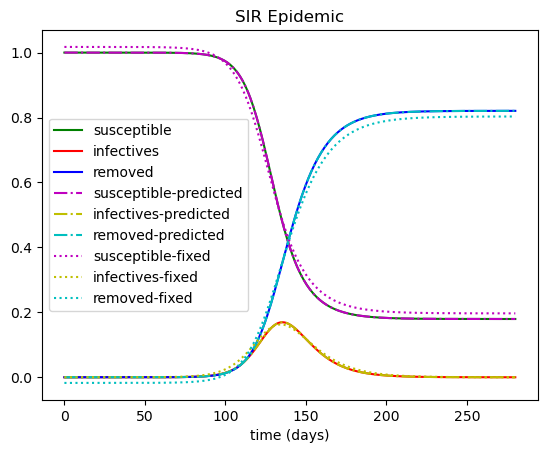

In [8]:
data_comparison = np.concatenate([sirdata, sirpredicted, sirfixed], axis=1)
data_attributes = [
    {"linestyle":"-", "label": "susceptible", "color":"g"}, 
    {"linestyle":"-", "label": "infectives" , "color":"r"},
    {"linestyle":"-", "label": "removed"    , "color":"b"},
    {"linestyle":"-.", "label": "susceptible-predicted", "color":"m"}, 
    {"linestyle":"-.", "label": "infectives-predicted" , "color":"y"},
    {"linestyle":"-.", "label": "removed-predicted"    , "color":"c"},
    {"linestyle":":", "label": "susceptible-fixed", "color":"m"}, 
    {"linestyle":":", "label": "infectives-fixed" , "color":"y"},
    {"linestyle":":", "label": "removed-fixed"    , "color":"c"}
]
comparison = configure_dataset(data_comparison, data_attributes) 
plot_dataset(comparison, tvalues)

In [9]:
def configure_mean_std(predicted, nsamples):
    std = np.sqrt(predicted*(1-predicted)/nsamples)
    return (predicted, std)

def plot_samples(sampled_infectives, true_infectives, predicted_mean_std):   
    mean, std = predicted_mean_std
    plt.plot(tvalues, sampled_infectives, label="sampled infectives", color="blue")
    plt.plot(tvalues, true_infectives, label="true infectives", color="red")
    plt.plot(tvalues, mean, label="predicted infectives", color="black")

    for mult in range(1,4):
        plt.fill_between(tvalues, mean - mult*std, mean + mult*std, color="grey", alpha=0.25/mult)
    plt.title("SIR Samples")
    plt.legend()


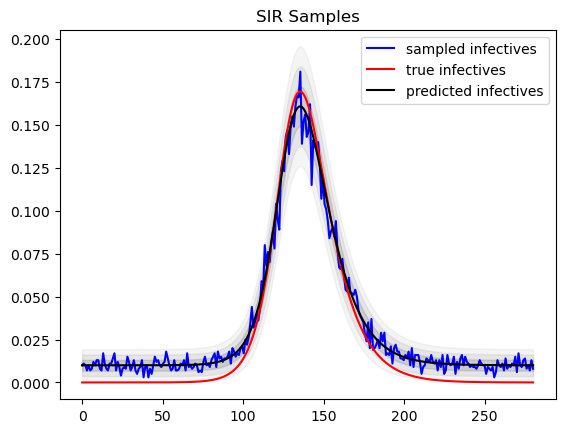

In [10]:
from sir_modelling import sample
ptp=0.9
pfp=0.01
nsamples =1000
true_infectives = sirdata[:, 1]
sampled_infectives = sample(true_infectives, ptp, pfp, nsamples)/nsamples
predicted = ptp*true_infectives + pfp*(1-true_infectives)
predicted_mean_std = configure_mean_std(predicted, nsamples)
plot_samples(sampled_infectives, true_infectives, predicted_mean_std)

In [11]:
from src.operators.base import check_dot_product, check_linearization
test_input = np.array([0.9, 0.1, 0.21, 0.11, 0.9, 0.1])
sir_sample_mod = sirmod.create_sampler()
check_linearization(sir_sample_mod, test_input)
check_dot_product(sir_sample_mod, test_input)

In [12]:
def plot_results(sirdata, sampled_infectives, sirpredicted, predicted_infectives, nsamples):
    fig, axs = plt.subplots(2,2) 
    
    mean, std = configure_mean_std(predicted_infectives, nsamples)
   
    axs[0,0].plot(tvalues, sampled_infectives, label="sampled infectives", color="blue")
    axs[0,0].plot(tvalues, mean, label="predicted infectives", color="black")

    for mult in range(1,4):
        axs[0,0].fill_between(tvalues, mean - mult*std, mean + mult*std, color="grey", alpha=0.25/mult)
    axs[0,0].legend()

    axs[0,1].plot(tvalues, sirdata[:,1], label="true infectives", color="red")
    axs[0,1].plot(tvalues, sirpredicted[:,1], label="modelled infectives", color="magenta")
    axs[0,1].legend()
    axs[1,0].plot(tvalues, sirdata[:, 0], linestyle="-", label="susceptible", color="green")
    axs[1,0].plot(tvalues, sirdata[:, 1], linestyle="-", label="infectives", color="red")
    axs[1,0].plot(tvalues, sirdata[:, 2], linestyle="-", label="removed", color="blue")
    axs[1,0].legend()
    axs[1,1].plot(tvalues, sirpredicted[:,0], linestyle="-", label="predicted-susceptible", color="cyan")
    axs[1,1].plot(tvalues, sirpredicted[:,1], linestyle="-", label="predicted-infectives", color="magenta")
    axs[1,1].plot(tvalues, sirpredicted[:,2], linestyle="-", label="predicted-removed", color="navy")
    axs[1,1].legend()
    plt.show()

In [13]:
from sir_inversion import SIRInversion, SIRFixedInversion
sirinv = SIRInversion(sirmod=sir_sample_mod, data=sampled_infectives[:,np.newaxis])
predicted_infectives , params, predicted_sir,  = sirinv(x0 = np.array([1.0, 0.0, 0.2, 0.1, 0.99, 0.01]))

shape=(6,)
1 : [1.00000000e+00 6.33314403e-07 2.00000000e-01 1.00000000e-01
 9.90000000e-01 1.00000000e-02]
2 : [1.00064734e+00 6.33332497e-07 2.03637124e-01 9.74636292e-02
 9.89950654e-01 9.43802565e-03]
3 : [1.00080958e+00 6.33352691e-07 2.07537917e-01 1.01469836e-01
 9.89384859e-01 3.79763272e-03]
4 : [1.00102741e+00 6.33332483e-07 2.22119173e-01 1.17341382e-01
 9.87123107e-01 1.41995914e-02]
5 : [9.99277709e-01 6.33333582e-07 2.21619767e-01 1.16525532e-01
 9.87309665e-01 1.35611598e-02]
6 : [9.98736247e-01 6.33335843e-07 2.19974342e-01 1.14786205e-01
 9.88522521e-01 1.21387021e-02]
7 : [9.99401341e-01 6.33339909e-07 2.15739808e-01 1.10873801e-01
 9.92502615e-01 8.86785843e-03]
8 : [1.00133131e+00 6.33339899e-07 2.15270285e-01 1.10879940e-01
 9.93986979e-01 8.47137278e-03]
9 : [1.00412690e+00 6.33339165e-07 2.15046709e-01 1.11293001e-01
 9.95724421e-01 8.38800013e-03]
10 : [1.01019689e+00 6.33337339e-07 2.14565846e-01 1.12178636e-01
 9.99438301e-01 8.31804666e-03]
11 : [1.02251727e+

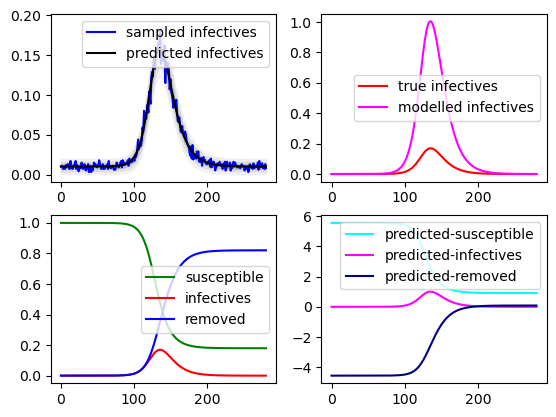

In [14]:
plot_results(sirdata, sampled_infectives, predicted_sir, predicted_infectives, nsamples)

In [15]:
sirfixedinv = SIRFixedInversion.from_sirmod(sirmod=sir_sample_mod, 
                                            data=sampled_infectives[:,np.newaxis],
                                            model0= np.array([0.2,0.1]))
predicted_infectives_fix, params, predicted_sir_fix =  sirfixedinv(x0 = np.array([1.0, 0.0, 0.99, 0.01]))



shape=(4,)
1 : [1.00000000e+00 6.33314403e-07 9.90000000e-01 1.00000000e-02]
2 : [1.00975342e+00 6.33344959e-07 9.89256507e-01 1.53277445e-03]
3 : [1.03184234e+00 6.33344946e-07 9.87886191e-01 5.62329995e-03]
4 : [1.02892092e+00 6.33345844e-07 8.87997044e-01 7.29979317e-03]
5 : [1.03087592e+00 6.33346894e-07 8.45028779e-01 8.15965345e-03]
6 : [1.03123749e+00 6.33346333e-07 8.43563256e-01 8.24402147e-03]
7 : [1.03131783e+00 6.33345650e-07 8.43593317e-01 8.24671003e-03]
8 : [1.03131888e+00 6.33345034e-07 8.43608134e-01 8.24633762e-03]
9 : [1.03132428e+00 6.33338325e-07 8.43684677e-01 8.24435906e-03]
10 : [1.03133050e+00 6.33324656e-07 8.43765634e-01 8.24225286e-03]
11 : [1.03133802e+00 6.33299542e-07 8.43853002e-01 8.23995827e-03]
12 : [1.03134824e+00 6.33253450e-07 8.43957127e-01 8.23719009e-03]
13 : [1.03136353e+00 6.33167451e-07 8.44091829e-01 8.23355423e-03]
14 : [1.03138792e+00 6.33004824e-07 8.44275450e-01 8.22850369e-03]
15 : [1.03142851e+00 6.32694901e-07 8.44532364e-01 8.2212660

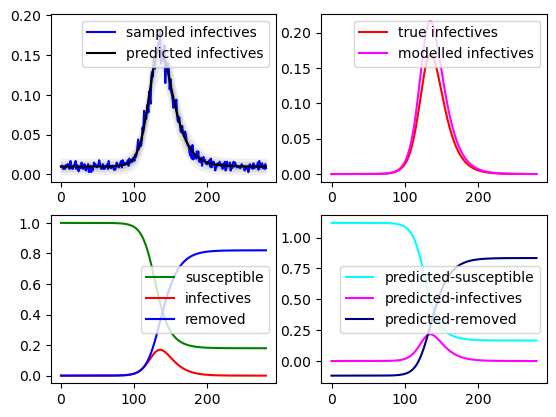

In [16]:
plot_results(sirdata, sampled_infectives, predicted_sir_fix, predicted_infectives_fix, nsamples)

In [ ]:
xstart = np.array([1.0, 0.0, 0.2, 0.1, 0.99, 0.01])
sirinv = SIRInversion(sirmod=sir_sample_mod, data=sampled_infectives[:,np.newaxis], regularizer=(xstart, 10))
predicted_infectives , params, predicted_sir,  = sirinv(x0 = xstart)

shape=(6,)
shape=(6,)
1 : [1.00000000e+00 6.33314385e-07 2.00000000e-01 1.00000000e-01
 9.90000000e-01 1.00000000e-02]
2 : [1.00061677e+00 6.33331624e-07 2.03465349e-01 9.75834172e-02
 9.89952985e-01 9.46456664e-03]
3 : [1.00072404e+00 6.33345157e-07 2.06063543e-01 1.00311934e-01
 9.89572453e-01 5.63870644e-03]
4 : [1.00075303e+00 6.33342230e-07 2.07533354e-01 1.01933184e-01
 9.89340898e-01 6.97759375e-03]
5 : [9.98264775e-01 6.33342994e-07 2.07163603e-01 1.01951620e-01
 9.88466260e-01 6.95959783e-03]
6 : [9.99743115e-01 6.33343270e-07 2.06797837e-01 1.02215507e-01
 9.89011539e-01 6.96487405e-03]
7 : [1.00065719e+00 6.33346154e-07 2.06985750e-01 1.02255219e-01
 9.89558455e-01 6.97682525e-03]
8 : [1.00074402e+00 6.33346234e-07 2.06966534e-01 1.02246041e-01
 9.89366200e-01 6.97692276e-03]
9 : [1.00072456e+00 6.33349307e-07 2.06955370e-01 1.02238329e-01
 9.89355353e-01 6.97317563e-03]
10 : [1.00071987e+00 6.33353945e-07 2.06952423e-01 1.02236230e-01
 9.89352784e-01 6.97228816e-03]
11 : [1

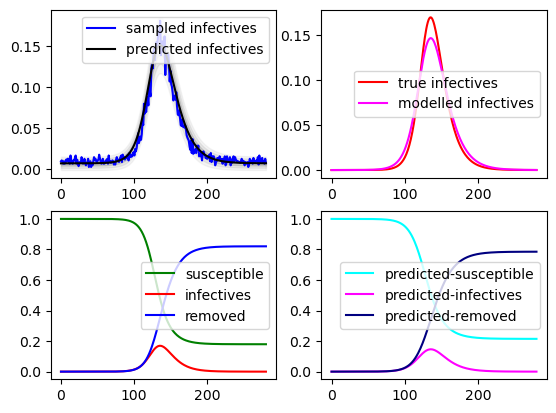

In [18]:
plot_results(sirdata, sampled_infectives, predicted_sir, predicted_infectives, nsamples)